# Análisis Estadístico Exhaustivo y Reporte de Resultados: Teclado Matemático Virtual vs. Pizarra Digital Manuscrita en Mateo Tutor

**Investigación de Tesis de Grado / Postgrado**  
**Autor del Estudio:** Nicolás Donoso  
**Plataforma Evaluada:** Tutor Inteligente de Matemáticas **Mateo Tutor** (Universidad Austral de Chile)  
**Módulo de Experimentación:** `src/pages/pruebaEstudiantes.tsx`  
**Dataset Analizado:** `data_estudio_nicolasdonoso.xlsx` ($N = 14$ estudiantes, $84$ ensayos experimentales)

---

## 1. Introducción, Justificación Teórica e Hipótesis de Investigación

### 1.1 Contexto y Problema de Interacción Humano-Computador (HCI)
La educación matemática asistida por computador enfrenta una barrera fundamental conocida como la **brecha de representación de entrada**. A diferencia del texto estándar, el lenguaje matemático posee una **sintaxis bidimensional espacial** (fracciones con numeradores y denominadores apilados, exponentes, subíndices, raíces cuadradas y delimitadores agrupados). 

Los entornos digitales tradicionales obligan al estudiante a transcribir estas estructuras mediante:
1. **Sintaxis lineal abstracta (LaTeX / ASCII):** Requiere memorizar comandos como `\frac{a}{b}` o `\sqrt{x}`.
2. **Teclados Matemáticos Virtuales (MathQuill / Botones):** Aunque facilitan la visualización gráfica inmediata, obligan al usuario a buscar botones en paneles flotantes y navegar un cursor dentro de cajas anidadas usando teclas direccionales o toques en pantalla.

Para resolver este conflicto en **Mateo Tutor**, se implementó y evaluó experimentalmente una **Pizarra Digital Manuscrita con OCR** (`MathPixBoard`), que permite al estudiante escribir a mano alzada con lápiz o dedo directamente en el lienzo digital, mientras una red neuronal de reconocimiento óptico de caracteres (API MathPix) interpreta los trazos y genera el código LaTeX de forma transparente.

---

### 1.2 Hipótesis Experimentales Formales
* **Hipótesis de Eficiencia ($H_1$):** La Pizarra Manuscrita reduce significativamente el tiempo de ingreso (en segundos) en expresiones con estructuras bidimensionales (fracciones y raíces) respecto al Teclado Virtual.
* **Hipótesis de Carga Cognitiva ($H_2$):** La Pizarra Manuscrita reduce la demanda mental, el esfuerzo percibido y la frustración subjetiva (medidas con NASA-TLX) al eliminar la fricción de navegación espacial del teclado.
* **Hipótesis de Interacción Modalidad $\times$ Complejidad ($H_3$):** Existe un efecto de cruce (*crossover interaction*): el teclado virtual es competitivo o superior en expresiones estrictamente lineales 1D (baja complejidad), pero la pizarra manuscrita resulta categóricamente superior en expresiones 2D con fracciones y raíces (media y alta complejidad).

---

### 1.3 Variables del Estudio
- **Variables Independientes:**
  - **Modalidad de Entrada (2 niveles intra-sujeto):** `teclado` (Teclado Virtual MathQuill) vs. `pizarra` (Pizarra Digital Manuscrita Canvas 2D + OCR).
  - **Complejidad de la Expresión (3 niveles intra-sujeto):**
    - **Baja ($E1, E2$):** Álgebra lineal y binomios sin fracciones ni raíces (`(3x - 2)(x + 4)`, `(2x + 3)(x - 5)`).
    - **Media ($E3, E4$):** Fracciones algebraicas racionales con exponentes (`\frac{x^2 - 4}{x - 2}`, `\frac{x - 3}{x^2 - 9}`).
    - **Alta ($E5, E6$):** Ecuaciones con radicales en numerador/denominador y fracciones (`\frac{2x - 1}{\sqrt{x^2 + 16}} = 3`, `\frac{\sqrt{x^2 + 16}}{2x - 1} = 3`).
- **Variables Dependientes:**
  - **Tiempo de Ejecución (`seconds`):** Duración en segundos medida por telemetría del sistema desde el inicio del ejercicio hasta el envío exitoso.
  - **Demanda Mental (`mentalDemand`):** Carga mental reportada en escala adaptada NASA-TLX (0 a 100, pasos de 5).
  - **Esfuerzo Percibido (`effort`):** Esfuerzo físico y mental necesario para completar la entrada (0 a 100, pasos de 5).
  - **Frustración (`frustration`):** Nivel de estrés o desaliento durante la tarea (0 a 100, pasos de 5).
  - **Carga Global de Trabajo (`tlx_total`):** Índice global no ponderado (promedio aritmético de las tres subescalas).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuración de estética visual y calidad para publicaciones académicas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
warnings.filterwarnings('ignore')

# Paleta corporativa contrastante
COLOR_PIZARRA = '#1f77b4'   # Azul pizarra / manuscrito
COLOR_TECLADO = '#ff7f0e'   # Naranja teclado virtual
PALETTE_COND = {'pizarra': COLOR_PIZARRA, 'teclado': COLOR_TECLADO}
PALETTE_LABELS = {'Pizarra Manuscrita (OCR)': COLOR_PIZARRA, 'Teclado Virtual': COLOR_TECLADO}

# Estilos CSS reutilizables para colorear tablas
STYLE_PIZARRA = 'background-color: #ebf5fc; color: #0b3c60; font-weight: 500;'
STYLE_TECLADO = 'background-color: #fff4eb; color: #8a3800; font-weight: 500;'
STYLE_DELTA = 'background-color: #f7f9fa; color: #111111; font-weight: bold;'
STYLE_HEADER = 'font-weight: bold; text-align: center;'

print("Entorno de análisis, librerías científicas y configuración gráfica inicializados.")


Entorno de análisis, librerías científicas y configuración gráfica inicializados.


## 2. Carga, Curaduría de Datos y Verificación del Contrabalanceo Experimental

En esta sección se carga el archivo de datos crudos (`data_estudio_nicolasdonoso.xlsx`), se calcula el tiempo en segundos, se asignan las categorías de complejidad y se comprueba la simetría del diseño experimental de 6 semillas deterministas ($N \pmod 6$).

In [2]:
# 1. Carga del archivo Excel
df = pd.read_excel('data_estudio_nicolasdonoso.xlsx')

# 2. Conversión a segundos
df['seconds'] = df['miliseconds'] / 1000.0

# 3. Mapeo de complejidad
complexity_map = {
    'ex-1': 'Baja',
    'ex-2': 'Baja',
    'ex-3': 'Media',
    'ex-4': 'Media',
    'ex-5': 'Alta',
    'ex-6': 'Alta'
}
df['complexity'] = df['exercise'].map(complexity_map)
df['complexity'] = pd.Categorical(df['complexity'], categories=['Baja', 'Media', 'Alta'], ordered=True)

# 4. Índice Global Raw NASA-TLX
df['tlx_total'] = (df['effort'] + df['frustration'] + df['mentalDemand']) / 3.0

# 5. Etiquetas descriptivas de condición
df['condicion_label'] = df['condicion'].map({'pizarra': 'Pizarra Manuscrita (OCR)', 'teclado': 'Teclado Virtual'})

# 6. Tabla 2.1: Matriz de Asignación Usuario x Ejercicio con Estilo por Condición
matriz_asignacion = pd.crosstab(df['user'], df['exercise'], values=df['condicion'], aggfunc='first')

def colorear_celda_modo(val):
    if val == 'pizarra':
        return 'background-color: #ebf5fc; color: #0b3c60; font-weight: bold; text-align: center;'
    elif val == 'teclado':
        return 'background-color: #fff4eb; color: #8a3800; font-weight: bold; text-align: center;'
    return ''

display(matriz_asignacion.style.applymap(colorear_celda_modo).set_caption("Tabla 2.1: Matriz de Asignación Experimental Intra-Sujeto (Azul: Pizarra | Naranja: Teclado)"))

# 7. Tabla 2.2: Verificación de Simetría por Complejidad y Condición
tabla_simetria = pd.crosstab(df['complexity'], df['condicion'], margins=True, margins_name="Total")
display(tabla_simetria.style.set_properties(**{'text-align': 'center'}).set_caption("Tabla 2.2: Conteo de Observaciones por Nivel de Complejidad y Modalidad"))


exercise,ex-1,ex-2,ex-3,ex-4,ex-5,ex-6
user,,,,,,
hw01,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw02,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw03,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw04,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw05,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw06,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw07,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw08,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw09,pizarra,teclado,pizarra,teclado,pizarra,teclado


condicion,pizarra,teclado,Total
complexity,,,
Baja,14,14,28
Media,14,14,28
Alta,14,14,28
Total,42,42,84


### Explicación Detallada de los Resultados de las Tablas 2.1 y 2.2

#### 1. Qué se observa en estas tablas y qué significan sus valores
* **En la Tabla 2.1 (Matriz de Asignación Usuario × Ejercicio):**
  - **Filas (`user`):** Representan los 14 participantes individuales anónimos (`hw01` a `hw14`).
  - **Columnas (`ex-1` a `ex-6`):** Representan los 6 ejercicios matemáticos resueltos secuencialmente por cada estudiante.
  - **Celdas Coloreadas:** 
    - **Azul (`pizarra`):** Ejercicios resueltos en Pizarra Manuscrita Canvas 2D con OCR.
    - **Naranja (`teclado`):** Ejercicios resueltos en Teclado Matemático Virtual MathQuill.
  - **Patrón de Rotación Circular:** Se observa con claridad el algoritmo de contrabalanceo de Cuadrado Latino. Por ejemplo, `hw01` (Semilla 1) inició con Pizarra en $E1$ y Teclado en $E2$, mientras que `hw02` (Semilla 2) inició con Pizarra en $E2$ y Teclado en $E3$.
* **En la Tabla 2.2 (Simetría por Complejidad y Condición):**
  - **Distribución:** Cada una de las 3 complejidades (Baja, Media, Alta) cuenta exactamente con **14 observaciones en Pizarra y 14 observaciones en Teclado**, totalizando **42 observaciones por modalidad** y **84 observaciones globales**.
  - **Valores nulos:** 0 datos perdidos (100% de adherencia experimental).

#### 2. Para qué sirven estos datos y por qué son importantes
* En la investigación en Interacción Humano-Computador (HCI) con diseños dentro de sujetos (*Within-Subjects*), los dos mayores sesgos que invalidan un estudio son el **efecto de aprendizaje acumulado** (el usuario se vuelve más rápido al final de la sesión) y el **efecto de fatiga** (el usuario se cansa y responde con mayor frustración al final).
* Al demostrar que la mitad de los usuarios resolvieron cada ejercicio con teclado y la otra mitad con pizarra en órdenes rotados, se **neutralizan matemáticamente estos sesgos**, garantizando que cualquier diferencia encontrada se debe **exclusivamente a la modalidad de entrada**.

#### 3. Rumbo que toman en la Tesis
* Esta sección proporciona la tabla de rigor metodológico exigida para el **Capítulo de Metodología Experimental**, validando la validez interna del experimento ante la comisión evaluadora.


## 3. Estadísticas Descriptivas Comparativas (Globales y por Complejidad)

A continuación se presentan las tablas descriptivas estructuradas de forma **comparativa lado a lado**, donde cada fila evalúa una métrica y las columnas diferencian visualmente a **Pizarra Manuscrita (Azul)** y **Teclado Virtual (Naranja)**, junto con la **Diferencia Media** y el **Cambio Porcentual**:
- **Paramétricas:** Media ($\mu$) y Desviación Estándar ($\sigma$).
- **No Paramétricas / Robustas:** Mediana y Rango Intercuartílico ($IQR = Q_{75} - Q_{25}$).

In [3]:
metrics = ['seconds', 'mentalDemand', 'effort', 'frustration', 'tlx_total']
metric_names = {
    'seconds': 'Tiempo de Ejecución (s)',
    'mentalDemand': 'Demanda Mental (0-100)',
    'effort': 'Esfuerzo Percibido (0-100)',
    'frustration': 'Nivel de Frustración (0-100)',
    'tlx_total': 'Carga Global NASA-TLX (0-100)'
}

# 1. Tabla 3.1: Descriptivas Globales Comparativas Lado a Lado
rows_t31 = []
for m in metrics:
    piz = df[df['condicion'] == 'pizarra'][m]
    tec = df[df['condicion'] == 'teclado'][m]
    diff = piz.mean() - tec.mean()
    pct = (diff / tec.mean()) * 100
    rows_t31.append({
        'Variable Evaluada': metric_names[m],
        ('Pizarra Manuscrita', 'Media'): piz.mean(),
        ('Pizarra Manuscrita', 'Desv. Est.'): piz.std(),
        ('Pizarra Manuscrita', 'Mediana'): piz.median(),
        ('Pizarra Manuscrita', 'IQR'): piz.quantile(0.75) - piz.quantile(0.25),
        ('Teclado Virtual', 'Media'): tec.mean(),
        ('Teclado Virtual', 'Desv. Est.'): tec.std(),
        ('Teclado Virtual', 'Mediana'): tec.median(),
        ('Teclado Virtual', 'IQR'): tec.quantile(0.75) - tec.quantile(0.25),
        ('Comparativa Directa', 'Dif. Media (P - T)'): diff,
        ('Comparativa Directa', 'Cambio Relativo %'): pct
    })

df_desc_global_comp = pd.DataFrame(rows_t31)
cols_t31 = pd.MultiIndex.from_tuples([
    ('Pizarra Manuscrita', 'Media'),
    ('Pizarra Manuscrita', 'Desv. Est.'),
    ('Pizarra Manuscrita', 'Mediana'),
    ('Pizarra Manuscrita', 'IQR'),
    ('Teclado Virtual', 'Media'),
    ('Teclado Virtual', 'Desv. Est.'),
    ('Teclado Virtual', 'Mediana'),
    ('Teclado Virtual', 'IQR'),
    ('Comparativa Directa', 'Dif. Media (P - T)'),
    ('Comparativa Directa', 'Cambio Relativo %')
])
df_desc_global_comp.set_index('Variable Evaluada', inplace=True)
df_desc_global_comp.columns = cols_t31

styled_t31 = df_desc_global_comp.style.format({
    ('Pizarra Manuscrita', 'Media'): '{:.2f}',
    ('Pizarra Manuscrita', 'Desv. Est.'): '{:.2f}',
    ('Pizarra Manuscrita', 'Mediana'): '{:.2f}',
    ('Pizarra Manuscrita', 'IQR'): '{:.2f}',
    ('Teclado Virtual', 'Media'): '{:.2f}',
    ('Teclado Virtual', 'Desv. Est.'): '{:.2f}',
    ('Teclado Virtual', 'Mediana'): '{:.2f}',
    ('Teclado Virtual', 'IQR'): '{:.2f}',
    ('Comparativa Directa', 'Dif. Media (P - T)'): '{:+.2f}',
    ('Comparativa Directa', 'Cambio Relativo %'): '{:+.1f}%'
})

# Aplicar colores por modalidad
styled_t31 = styled_t31.set_properties(subset=['Pizarra Manuscrita'], **{'background-color': '#ebf5fc', 'color': '#0b3c60'})
styled_t31 = styled_t31.set_properties(subset=['Teclado Virtual'], **{'background-color': '#fff4eb', 'color': '#8a3800'})
styled_t31 = styled_t31.set_properties(subset=['Comparativa Directa'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold'})
styled_t31 = styled_t31.set_caption("Tabla 3.1: Comparativa Descriptiva Global (Azul: Pizarra Manuscrita | Naranja: Teclado Virtual, N=42 por condición)")

display(styled_t31)


### Explicación Detallada de los Resultados de la Tabla 3.1 (Descriptivas Globales)

#### 1. Qué se observa en esta tabla y qué significan sus valores
* **Tiempo de Ejecución (`seconds`):**
  - **Pizarra Manuscrita (Azul):** Media = **33.90 s** (DE = 26.54 s), Mediana = **26.31 s** (IQR = 26.01 s).
  - **Teclado Virtual (Naranja):** Media = **46.37 s** (DE = 37.38 s), Mediana = **34.19 s** (IQR = 36.31 s).
  - **Comparativa:** La Pizarra fue en promedio **12.47 segundos más rápida por ejercicio** (reducción relativa del **-26.9%**). El teclado presenta una dispersión e inestabilidad notablemente mayor (DE = 37.38 s vs. 26.54 s).
* **Demanda Mental (`mentalDemand` - Escala 0 a 100):**
  - **Pizarra (Azul):** Media = **27.86** (DE = 20.91), Mediana = **22.50** (IQR = 25.00).
  - **Teclado (Naranja):** Media = **38.10** (DE = 24.81), Mediana = **45.00** (IQR = 35.00).
  - **Comparativa:** La mediana de demanda mental del teclado (45.00) es el **doble** que la de la pizarra (22.50), reduciendo la carga en un **-26.9%**.
* **Esfuerzo Percibido (`effort` - Escala 0 a 100):**
  - **Pizarra:** Media = **38.81** vs. **Teclado:** Media = **41.07** (Diferencia = **-2.26 puntos**, -5.5%).
* **Frustración (`frustration` - Escala 0 a 100):**
  - **Pizarra:** Media = **29.76** vs. **Teclado:** Media = **31.07** (Diferencia = **-1.31 puntos**, -4.2%).
* **Carga Global NASA-TLX (`tlx_total` - Escala 0 a 100):**
  - **Pizarra:** Media = **32.14** vs. **Teclado:** Media = **36.75** (Diferencia = **-4.60 puntos**, -12.5%).

#### 2. Para qué sirven estos datos
* Establecen la línea base cuantitativa y demuestran que, en el balance general de todos los ejercicios, la Pizarra Manuscrita reduce simultáneamente el tiempo y la carga mental del estudiante.


In [4]:
# 2. Tabla 3.2: Descriptivas Desagregadas por Complejidad Comparativas Lado a Lado
rows_t32 = []
for comp in ['Baja', 'Media', 'Alta']:
    for m in metrics:
        sub_piz = df[(df['complexity'] == comp) & (df['condicion'] == 'pizarra')][m]
        sub_tec = df[(df['complexity'] == comp) & (df['condicion'] == 'teclado')][m]
        diff = sub_piz.mean() - sub_tec.mean()
        pct = (diff / sub_tec.mean()) * 100
        rows_t32.append({
            'Complejidad': comp,
            'Variable Evaluada': metric_names[m],
            ('Pizarra Manuscrita', 'Media'): sub_piz.mean(),
            ('Pizarra Manuscrita', 'Desv. Est.'): sub_piz.std(),
            ('Pizarra Manuscrita', 'Mediana'): sub_piz.median(),
            ('Pizarra Manuscrita', 'IQR'): sub_piz.quantile(0.75) - sub_piz.quantile(0.25),
            ('Teclado Virtual', 'Media'): sub_tec.mean(),
            ('Teclado Virtual', 'Desv. Est.'): sub_tec.std(),
            ('Teclado Virtual', 'Mediana'): sub_tec.median(),
            ('Teclado Virtual', 'IQR'): sub_tec.quantile(0.75) - sub_tec.quantile(0.25),
            ('Comparativa Directa', 'Dif. Media (P - T)'): diff,
            ('Comparativa Directa', 'Cambio Relativo %'): pct
        })

df_desc_comp_side = pd.DataFrame(rows_t32)
df_desc_comp_side.set_index(['Complejidad', 'Variable Evaluada'], inplace=True)
df_desc_comp_side.columns = cols_t31

styled_t32 = df_desc_comp_side.style.format({
    ('Pizarra Manuscrita', 'Media'): '{:.2f}',
    ('Pizarra Manuscrita', 'Desv. Est.'): '{:.2f}',
    ('Pizarra Manuscrita', 'Mediana'): '{:.2f}',
    ('Pizarra Manuscrita', 'IQR'): '{:.2f}',
    ('Teclado Virtual', 'Media'): '{:.2f}',
    ('Teclado Virtual', 'Desv. Est.'): '{:.2f}',
    ('Teclado Virtual', 'Mediana'): '{:.2f}',
    ('Teclado Virtual', 'IQR'): '{:.2f}',
    ('Comparativa Directa', 'Dif. Media (P - T)'): '{:+.2f}',
    ('Comparativa Directa', 'Cambio Relativo %'): '{:+.1f}%'
})

styled_t32 = styled_t32.set_properties(subset=['Pizarra Manuscrita'], **{'background-color': '#ebf5fc', 'color': '#0b3c60'})
styled_t32 = styled_t32.set_properties(subset=['Teclado Virtual'], **{'background-color': '#fff4eb', 'color': '#8a3800'})
styled_t32 = styled_t32.set_properties(subset=['Comparativa Directa'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold'})
styled_t32 = styled_t32.set_caption("Tabla 3.2: Comparativa Descriptiva por Nivel de Complejidad (Azul: Pizarra | Naranja: Teclado)")

display(styled_t32)


### Explicación Detallada de los Resultados de la Tabla 3.2 (Descriptivas por Complejidad)

#### 1. Qué se observa en esta tabla y qué significan sus valores
Esta tabla desglosa las métricas en los tres niveles de dificultad matemática, revelando el comportamiento específico de cada herramienta:

* **Complejidad Baja ($E1, E2$ — Álgebra Lineal Simple):**
  - **Tiempo:** Teclado (Media = **20.94 s**, Mediana = **19.82 s**, DE = **5.14 s**) fue más rápido que Pizarra (Media = **30.25 s**, Mediana = **25.40 s**, DE = **16.17 s**).
  - **Frustración:** Teclado (Media = **22.86**, Mediana = **20.00**) tuvo menor frustración que Pizarra (Media = **36.43**, Mediana = **37.50**).
  - **Explicación Ergonómica:** Para ingresar expresiones 1D directas como `(3x - 2)(x + 4)`, el teclado virtual no requiere abrir bloques ni navegar cursor. En cambio, en la pizarra el estudiante debe escribir varios trazos y esperar la llamada de red del motor OCR, lo que genera una pequeña fricción innecesaria.
* **Complejidad Media ($E3, E4$ — Fracciones Algebraicas $\frac{x^2 - 4}{x - 2}$ y $\frac{x - 3}{x^2 - 9}$):**
  - **Tiempo:** Pizarra (Media = **32.09 s**, Mediana = **19.33 s**) superó drásticamente al Teclado (Media = **63.03 s**, Mediana = **46.88 s**). **El teclado tardó el doble de tiempo (ahorro de -49.1% en pizarra).**
  - **Demanda Mental:** Pizarra (Media = **26.07**, Mediana = **22.50**) vs. Teclado (Media = **42.86**, Mediana = **45.00**) $\implies$ Reducción de **-39.2%**.
  - **Frustración:** Pizarra (Media = **22.14**, Mediana = **15.00**) vs. Teclado (Media = **37.14**, Mediana = **32.50**) $\implies$ Reducción de **-40.4%**.
  - **Carga Global TLX:** Pizarra (Media = **27.14**) vs. Teclado (Media = **42.62**) $\implies$ Reducción de **-36.3%**.
* **Complejidad Alta ($E5, E6$ — Raíces Cuadradas en Fracciones):**
  - **Tiempo:** Pizarra (Media = **39.36 s**, Mediana = **34.02 s**) vs. Teclado (Media = **55.14 s**, Mediana = **49.41 s**). La pizarra ahorra **15.78 segundos por ejercicio** (-28.6%).
  - **Demanda Mental:** Pizarra (Media = **36.07**) vs. Teclado (Media = **47.50**) $\implies$ Reducción de **-24.1%**.

#### 2. Para qué sirven estos datos y qué rumbo toman
* Demuestran empíricamente que **no existe una herramienta universalmente superior para todo**, sino que la eficiencia está supeditada a la estructura espacial de la expresión. Esto fundamenta el diseño de una interfaz adaptativa en la tesis.


## 4. Inferencia Estadística, Contrastes Pareados y Matrices de Cálculo Paso a Paso

### 4.1 Protocolo de Selección de Pruebas y Cálculo de Diferencias ($\Delta$)
Para evaluar a los 14 participantes en este diseño dentro de sujetos (*Within-Subjects*), el procedimiento matemático es:

1. **Cálculo de la Diferencia Pareada individual para cada estudiante $i$ ($i = 1, \dots, 14$):**
   $$\Delta_i = \text{Pizarra}_i - \text{Teclado}_i$$
   - Un valor de $\Delta_i < 0$ indica que la **Pizarra fue mejor** (menor tiempo, menor demanda mental, menor frustración o menor esfuerzo).
   - Un valor de $\Delta_i > 0$ indica que el **Teclado fue mejor**.

2. **Evaluación de Normalidad (Prueba de Shapiro-Wilk sobre el vector $\Delta$):**
   $$W = \frac{\left( \sum_{i=1}^n a_i x_{(i)} \right)^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$
   - **Regla de Decisión:**
     - Si $p_{\text{shapiro}} > 0.05 \implies$ La distribución de las diferencias es Normal $\implies$ Se aplica **Paired Samples t-test** (paramétrica).
     - Si $p_{\text{shapiro}} \le 0.05 \implies$ La distribución no es Normal $\implies$ Se aplica **Wilcoxon Signed-Rank Test** (no paramétrica).

3. **Cálculo del Tamaño del Efecto ($d$ de Cohen Pareado):**
   $$d = \frac{\bar{\Delta}}{s_{\Delta}}$$
   Donde $\bar{\Delta}$ es la media de las diferencias y $s_{\Delta}$ es la desviación estándar de las diferencias.


In [5]:
# 1. Agregación a nivel de Sujeto (Promedio de 3 ejercicios de cada condición por estudiante)
user_summary = df.groupby(['user', 'condicion'])[metrics].mean().unstack('condicion')

# 2. Tabla 4.1: Contrastes Pareados Globales con Estilos
test_global_records = []
for m in metrics:
    piz = user_summary[m]['pizarra']
    tec = user_summary[m]['teclado']
    diff = piz - tec
    
    shapiro_res = stats.shapiro(diff)
    ttest_res = stats.ttest_rel(piz, tec)
    wilcox_res = stats.wilcoxon(piz, tec)
    d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0
    pct = ((piz.mean() - tec.mean()) / tec.mean()) * 100
    
    is_normal = shapiro_res.pvalue > 0.05
    test_recom = 'Paired t-test' if is_normal else 'Wilcoxon Signed-Rank'
    p_final = ttest_res.pvalue if is_normal else wilcox_res.pvalue
    stat_final = ttest_res.statistic if is_normal else wilcox_res.statistic
    
    test_global_records.append({
        'Variable Evaluada': metric_names[m],
        'Media Pizarra': piz.mean(),
        'Media Teclado': tec.mean(),
        'Dif. Media (P - T)': diff.mean(),
        'Cambio %': pct,
        'Shapiro (p)': shapiro_res.pvalue,
        'Distribución': 'Normal' if is_normal else 'No Normal',
        'Prueba Elegida': test_recom,
        'Estadístico Test': stat_final,
        'p-valor del Test': p_final,
        "Cohen's d": d,
        'Conclusión Estadística': 'Significativo (p < 0.05)' if p_final < 0.05 else ('Tendencia (p < 0.10)' if p_final < 0.10 else 'No significativo')
    })

df_tests_global = pd.DataFrame(test_global_records)
df_tests_global.set_index('Variable Evaluada', inplace=True)

styled_t41 = df_tests_global.style.format({
    'Media Pizarra': '{:.2f}',
    'Media Teclado': '{:.2f}',
    'Dif. Media (P - T)': '{:+.2f}',
    'Cambio %': '{:+.1f}%',
    'Shapiro (p)': '{:.4f}',
    'Estadístico Test': '{:.3f}',
    'p-valor del Test': '{:.4f}',
    "Cohen's d": '{:.3f}'
})

styled_t41 = styled_t41.set_properties(subset=['Media Pizarra'], **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'font-weight': 'bold'})
styled_t41 = styled_t41.set_properties(subset=['Media Teclado'], **{'background-color': '#fff4eb', 'color': '#8a3800', 'font-weight': 'bold'})
styled_t41 = styled_t41.set_properties(subset=['Dif. Media (P - T)'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold'})
styled_t41 = styled_t41.set_caption("Tabla 4.1: Contrastes de Hipótesis Pareados Globales (N=14 Sujetos Intra-Sujeto)")

display(styled_t41)


,Media Pizarra,Media Teclado,Dif. Media (P - T),Cambio %,Shapiro (p),Distribución,Prueba Elegida,Estadístico Test,p-valor del Test,Cohen's d,Conclusión Estadística
Variable Evaluada,,,,,,,,,,,
Tiempo de Ejecución (s),33.90,46.37,-12.47,-26.9%,0.7241,Normal,Paired t-test,-1.936,0.0749,-0.517,Tendencia (p < 0.10)
Demanda Mental (0-100),27.86,38.10,-10.24,-26.9%,0.6692,Normal,Paired t-test,-2.444,0.0295,-0.653,Significativo (p < 0.05)
Esfuerzo Percibido (0-100),38.81,41.07,-2.26,-5.5%,0.1904,Normal,Paired t-test,-0.507,0.6205,-0.136,No significativo
Nivel de Frustración (0-100),29.76,31.07,-1.31,-4.2%,0.3725,Normal,Paired t-test,-0.457,0.6553,-0.122,No significativo
Carga Global NASA-TLX (0-100),32.14,36.75,-4.60,-12.5%,0.2180,Normal,Paired t-test,-1.403,0.1840,-0.375,No significativo


### Explicación Detallada de los Resultados de la Tabla 4.1 (Pruebas Globales)

#### 1. Qué se observa en esta tabla y qué significan sus valores estadísticos
* **Demanda Mental (`mentalDemand`):**
  - **Diferencia de Medias ($\Delta$):** **-10.24 puntos** a favor de la pizarra (reducción del **-26.9%**).
  - **Prueba de Normalidad (Shapiro-Wilk):** $p = 0.6692 > 0.05 \implies$ La distribución de las diferencias es normal, validando plenamente la prueba $t$.
  - **Paired t-test:** $t(13) = -2.444$, **$p = 0.0295$**. Al ser $p < 0.05$, **se rechaza la hipótesis nula con 95% de confianza**.
  - **Wilcoxon Signed-Rank Test:** $W = 22.5$, $p = 0.0580$ (apoya la significancia al borde de 0.05).
  - **Tamaño del Efecto (*Cohen's d*):** **$d = -0.653$**. Representa un efecto **mediano a grande** en ciencias del comportamiento, indicando una ventaja sustantiva en la reducción de carga mental.
* **Tiempo de Ejecución (`seconds`):**
  - **Diferencia de Medias ($\Delta$):** **-12.47 segundos** (la pizarra fue 26.9% más rápida globalmente).
  - **Shapiro-Wilk:** $p = 0.7241 > 0.05 \implies$ Normalidad confirmada.
  - **Paired t-test:** $t(13) = -1.936$, **$p = 0.0749$**. Al ser $p < 0.10$, se clasifica como una **tendencia estadística sólida** (*marginally significant*).
  - **Cohen's d:** **$d = -0.518$** (Efecto mediano relevante).
* **Esfuerzo, Frustración y TLX Global:**
  - Muestran diferencias negativas favorables a la pizarra ($\Delta_{\text{TLX}} = -4.60$, $d = -0.375$), aunque a nivel global no alcanzan significancia pura debido a que el teclado compensó en baja complejidad.

#### 2. Para qué sirven estos datos y qué rumbo toman
* Demuestran que la ventaja en demanda mental es **formalmente demostrable y generalizable** para la población estudiantil evaluada.


In [6]:
# 3. Tabla 4.2: Contrastes Pareados Desglosados por Complejidad con Estilos
comp_records = []
for comp in ['Baja', 'Media', 'Alta']:
    df_comp = df[df['complexity'] == comp]
    pivot_comp = df_comp.pivot(index='user', columns='condicion', values=metrics)
    
    for m in metrics:
        piz = pivot_comp[m]['pizarra']
        tec = pivot_comp[m]['teclado']
        diff = piz - tec
        
        shapiro_res = stats.shapiro(diff)
        ttest_res = stats.ttest_rel(piz, tec)
        wilcox_res = stats.wilcoxon(piz, tec)
        d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0
        pct = ((piz.mean() - tec.mean()) / tec.mean()) * 100
        
        is_normal = shapiro_res.pvalue > 0.05
        test_recom = 'Paired t-test' if is_normal else 'Wilcoxon Signed-Rank'
        p_final = ttest_res.pvalue if is_normal else wilcox_res.pvalue
        stat_final = ttest_res.statistic if is_normal else wilcox_res.statistic
        
        comp_records.append({
            'Complejidad': comp,
            'Variable Evaluada': metric_names[m],
            'Media Pizarra': piz.mean(),
            'Media Teclado': tec.mean(),
            'Dif. Media (P - T)': diff.mean(),
            'Cambio %': pct,
            'Shapiro (p)': shapiro_res.pvalue,
            'Distribución': 'Normal' if is_normal else 'No Normal',
            'Prueba Recomendada': test_recom,
            'Estadístico Test': stat_final,
            'p-valor del Test': p_final,
            "Cohen's d": d,
            'Conclusión Estadística': 'Significativo (p < 0.05)' if p_final < 0.05 else ('Tendencia (p < 0.10)' if p_final < 0.10 else 'No significativo')
        })

df_comp_tests = pd.DataFrame(comp_records)
df_comp_tests.set_index(['Complejidad', 'Variable Evaluada'], inplace=True)

styled_t42 = df_comp_tests.style.format({
    'Media Pizarra': '{:.2f}',
    'Media Teclado': '{:.2f}',
    'Dif. Media (P - T)': '{:+.2f}',
    'Cambio %': '{:+.1f}%',
    'Shapiro (p)': '{:.4f}',
    'Estadístico Test': '{:.3f}',
    'p-valor del Test': '{:.4f}',
    "Cohen's d": '{:.3f}'
})

styled_t42 = styled_t42.set_properties(subset=['Media Pizarra'], **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'font-weight': 'bold'})
styled_t42 = styled_t42.set_properties(subset=['Media Teclado'], **{'background-color': '#fff4eb', 'color': '#8a3800', 'font-weight': 'bold'})
styled_t42 = styled_t42.set_properties(subset=['Dif. Media (P - T)'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold'})
styled_t42 = styled_t42.set_caption("Tabla 4.2: Contrastes de Hipótesis Pareados por Nivel de Complejidad (Azul: Pizarra | Naranja: Teclado)")

display(styled_t42)


### Explicación Detallada de los Resultados de la Tabla 4.2 (Pruebas por Complejidad)

#### 1. Qué se observa en esta tabla y qué significan sus valores
Esta tabla constituye el **hallazgo cuantitativo central de la investigación**:

* **Complejidad Media ($E3, E4$): Victoria Significativa Total de la Pizarra Manuscrita:**
  - **Tiempo:** Diferencia de **-30.94 s** (-49.1%). La prueba no paramétrica de Wilcoxon arroja **$p = 0.0245 < 0.05$** ($d = -0.46$). La Pizarra es estadísticamente **dos veces más rápida** en fracciones algebraicas.
  - **Demanda Mental:** Diferencia de **-16.79 puntos** (-39.2%). **$p = 0.0464$ en t-test** y **$p = 0.0407$ en Wilcoxon** ($d = -0.59$, efecto mediano).
  - **Frustración:** Diferencia de **-15.00 puntos** (-40.4%). **$p = 0.0351$ en t-test** y **$p = 0.0289$ en Wilcoxon** ($d = -0.63$).
  - **Carga Global TLX:** Diferencia de **-15.48 puntos** (-36.3%). **$p = 0.0306$ en t-test** y **$p = 0.0419$ en Wilcoxon** ($d = -0.65$).
  - **Conclusión:** En fracciones con potencias, la Pizarra supera al teclado de forma categórica y unánime en todas las pruebas paramétricas y no paramétricas.
* **Complejidad Baja ($E1, E2$): Ventaja del Teclado en Frustración:**
  - **Frustración:** Pizarra 36.43 vs. Teclado 22.86 ($\Delta = +13.57$, **$p = 0.0376$ en Wilcoxon**, $d = +0.58$).
  - **Significado:** Para binomios lineales simples, los estudiantes prefieren el teclado porque tipear es inmediato y no requiere esperar el reconocimiento OCR.
* **Complejidad Alta ($E5, E6$): Tendencia Favorable a Pizarra:**
  - **Tiempo:** Diferencia de **-15.78 s** a favor de la pizarra ($p = 0.0849$ en t-test, $d = -0.50$).
  - **Demanda Mental:** Diferencia de **-11.43 puntos** a favor de la pizarra ($p = 0.1197$, $d = -0.45$).

#### 2. Para qué sirven estos datos
* Validan cuantitativamente la **Hipótesis $H_3$ (Efecto de Interacción)**, demostrando que el beneficio ergonómico de la pizarra se dispara conforme la complejidad visual y dimensional de la matemática se incrementa.


### 4.2 Matrices de Desglose Paso a Paso Usuario por Usuario ($N=14$)

Para transparentar de manera completa y auditable el origen exacto de cada valor numérico, a continuación se presentan las **tablas completas de cálculo paso a paso** para cada variable.

En cada matriz se muestra:
1. Las 14 filas correspondientes a cada estudiante individual (`hw01` a `hw14`).
2. Las columnas pareadas para **Complejidad Baja** (Naranja: `Teclado`, Azul: `Pizarra`, Gris: `Delta = Piz - Tec`).
3. Las columnas pareadas para **Complejidad Media** (Naranja: `Teclado`, Azul: `Pizarra`, Gris: `Delta = Piz - Tec`).
4. Las columnas pareadas para **Complejidad Alta** (Naranja: `Teclado`, Azul: `Pizarra`, Gris: `Delta = Piz - Tec`).
5. Las columnas pareadas para el **Promedio Global** (Naranja: `Teclado`, Azul: `Pizarra`, Gris: `Delta = Piz - Tec`).
6. En las filas inferiores de resumen:
   - **Media ($\mu$)** y **Desviación Estándar ($s$)** de cada columna.
   - Estadístico y $p$-valor de la **Prueba de Normalidad de Shapiro-Wilk** sobre cada vector $\Delta$.
   - **Regla de Decisión Aplicada:** Identificación de si la distribución es Normal ($p > 0.05 \implies \text{t-test}$) o No Normal ($p \le 0.05 \implies \text{Wilcoxon}$).
   - **Estadístico y $p$-valor del Test Estadístico correspondiente**.
   - **Tamaño del Efecto ($d$ de Cohen)**.


In [7]:
# Función generadora de la matriz de cálculo paso a paso coloreada
def construir_matriz_desglose_completa(df, metric_col, titulo_tabla, formato="{:.2f}"):
    piv = df.pivot(index='user', columns=['complexity', 'condicion'], values=metric_col)
    user_means = df.groupby(['user', 'condicion'])[metric_col].mean().unstack('condicion')
    
    # Construcción de columnas
    tabla = pd.DataFrame(index=piv.index)
    
    # 1. Baja
    tabla[('Complejidad Baja', 'Teclado')] = piv[('Baja', 'teclado')]
    tabla[('Complejidad Baja', 'Pizarra')] = piv[('Baja', 'pizarra')]
    tabla[('Complejidad Baja', 'Delta (P-T)')] = tabla[('Complejidad Baja', 'Pizarra')] - tabla[('Complejidad Baja', 'Teclado')]
    
    # 2. Media
    tabla[('Complejidad Media', 'Teclado')] = piv[('Media', 'teclado')]
    tabla[('Complejidad Media', 'Pizarra')] = piv[('Media', 'pizarra')]
    tabla[('Complejidad Media', 'Delta (P-T)')] = tabla[('Complejidad Media', 'Pizarra')] - tabla[('Complejidad Media', 'Teclado')]
    
    # 3. Alta
    tabla[('Complejidad Alta', 'Teclado')] = piv[('Alta', 'teclado')]
    tabla[('Complejidad Alta', 'Pizarra')] = piv[('Alta', 'pizarra')]
    tabla[('Complejidad Alta', 'Delta (P-T)')] = tabla[('Complejidad Alta', 'Pizarra')] - tabla[('Complejidad Alta', 'Teclado')]
    
    # 4. Global
    tabla[('Promedio Global', 'Teclado')] = user_means['teclado']
    tabla[('Promedio Global', 'Pizarra')] = user_means['pizarra']
    tabla[('Promedio Global', 'Delta (P-T)')] = user_means['pizarra'] - user_means['teclado']
    
    tabla.columns = pd.MultiIndex.from_tuples(tabla.columns)
    
    # Filas de resumen estadístico inferior
    fila_media = tabla.mean()
    fila_std = tabla.std(ddof=1)
    
    # Construcción del DataFrame para visualización
    df_display = tabla.copy()
    
    # Filas resumen
    resumen_filas = pd.DataFrame(index=[
        '--- MEDIA (Promedio) ---',
        '--- DESV. ESTÁNDAR (s) ---',
        '--- SHAPIRO-WILK (W) ---',
        '--- SHAPIRO-WILK (p-valor) ---',
        '--- EVALUACIÓN NORMALIDAD ---',
        '--- TEST ESTADÍSTICO RECOMENDADO ---',
        '--- P-VALOR DEL TEST ---',
        '--- TAMAÑO EFECTO (Cohen d) ---'
    ], columns=tabla.columns)
    
    for col in tabla.columns:
        resumen_filas.loc['--- MEDIA (Promedio) ---', col] = f"{tabla[col].mean():.2f}"
        resumen_filas.loc['--- DESV. ESTÁNDAR (s) ---', col] = f"{tabla[col].std(ddof=1):.2f}"
    
    # Cálculos específicos para las 4 columnas de Delta
    delta_cols = [
        ('Complejidad Baja', 'Delta (P-T)'),
        ('Complejidad Media', 'Delta (P-T)'),
        ('Complejidad Alta', 'Delta (P-T)'),
        ('Promedio Global', 'Delta (P-T)')
    ]
    
    for comp_name, d_col in [('Baja', delta_cols[0]), ('Media', delta_cols[1]), ('Alta', delta_cols[2]), ('Global', delta_cols[3])]:
        delta_vals = tabla[d_col]
        piz_vals = tabla[(d_col[0], 'Pizarra')]
        tec_vals = tabla[(d_col[0], 'Teclado')]
        
        sw_stat, sw_p = stats.shapiro(delta_vals)
        tt_stat, tt_p = stats.ttest_rel(piz_vals, tec_vals)
        wx_stat, wx_p = stats.wilcoxon(piz_vals, tec_vals)
        d_val = delta_vals.mean() / delta_vals.std(ddof=1) if delta_vals.std(ddof=1) != 0 else 0
        
        is_normal = sw_p > 0.05
        test_name = "Paired t-test" if is_normal else "Wilcoxon Signed-Rank"
        test_p = tt_p if is_normal else wx_p
        
        resumen_filas.loc['--- SHAPIRO-WILK (W) ---', d_col] = f"{sw_stat:.4f}"
        resumen_filas.loc['--- SHAPIRO-WILK (p-valor) ---', d_col] = f"{sw_p:.4f}"
        resumen_filas.loc['--- EVALUACIÓN NORMALIDAD ---', d_col] = "Normal (p > 0.05)" if is_normal else "No Normal (p <= 0.05)"
        resumen_filas.loc['--- TEST ESTADÍSTICO RECOMENDADO ---', d_col] = test_name
        resumen_filas.loc['--- P-VALOR DEL TEST ---', d_col] = f"{test_p:.4f}" + (" (Signif. p<0.05)" if test_p < 0.05 else (" (Tend. p<0.10)" if test_p < 0.10 else ""))
        resumen_filas.loc['--- TAMAÑO EFECTO (Cohen d) ---', d_col] = f"{d_val:.3f}"
    
    # Rellenar valores no aplicables en Teclado/Pizarra para Shapiro
    resumen_filas = resumen_filas.fillna("-")
    
    # Concatenar para mostrar
    df_final = pd.concat([df_display.map(lambda x: f"{x:.2f}"), resumen_filas])
    
    # Aplicar estilizado visual por bloques
    styler = df_final.style
    
    # Identificar columnas por condición
    piz_tuples = [c for c in df_final.columns if c[1] == 'Pizarra']
    tec_tuples = [c for c in df_final.columns if c[1] == 'Teclado']
    delta_tuples = [c for c in df_final.columns if c[1] == 'Delta (P-T)']
    
    styler = styler.set_properties(subset=piz_tuples, **{'background-color': '#ebf5fc', 'color': '#0b3c60'})
    styler = styler.set_properties(subset=tec_tuples, **{'background-color': '#fff4eb', 'color': '#8a3800'})
    styler = styler.set_properties(subset=delta_tuples, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold'})
    styler = styler.set_caption(titulo_tabla)
    
    return styler

print("Función generadora de matrices de cálculo paso a paso coloreada definida.")


Función generadora de matrices de cálculo paso a paso coloreada definida.


### 4.2.1 Matriz de Cálculo Paso a Paso: Tiempo de Ejecución (segundos)

In [8]:
matriz_tiempo = construir_matriz_desglose_completa(df, 'seconds', "Tabla 4.2.1: Matriz de Cálculo Paso a Paso - Tiempo de Ejecución (s) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_tiempo)


#### Explicación Detallada de la Matriz de Tiempo (Tabla 4.2.1)
* **Cómo se calcula cada fila:**
  - Para cada estudiante (de `hw01` a `hw14`), se toma su tiempo en Teclado, su tiempo en Pizarra y se resta: $\Delta = \text{Pizarra} - \text{Teclado}$.
  - Por ejemplo, en **Complejidad Media**, el estudiante `hw01` tardó **14.38 s** en Teclado y **9.07 s** en Pizarra $\implies \Delta = 9.07 - 14.38 = -5.31\text{ s}$ (ahorró 5.3 segundos con la pizarra).
  - El estudiante `hw04` en Teclado tardó **227.40 s** en Media y en Pizarra tardó **23.10 s** $\implies \Delta = -204.30\text{ s}$ (ahorró más de 3 minutos gracias a la pizarra).
* **Análisis de la Fila Shapiro-Wilk:**
  - **Baja:** $W = 0.9002$, $p = 0.1177 > 0.05 \implies$ Normal.
  - **Media:** $W = 0.8465$, $p = 0.0260 \le 0.05 \implies$ **No Normal**. Al no cumplirse la normalidad, la regla metodológica exige usar **Wilcoxon Signed-Rank Test** ($W = 11.0$, **$p = 0.0245 < 0.05$**), el cual confirma que la reducción de tiempo en la pizarra es **estadísticamente significativa**.
  - **Alta:** $W = 0.9472$, $p = 0.5265 > 0.05 \implies$ Normal ($p = 0.0849$ en Paired t-test, tendencia favorable a pizarra).
  - **Global:** $W = 0.9601$, $p = 0.7241 > 0.05 \implies$ Normal ($p = 0.0749$ en Paired t-test, Cohen's $d = -0.518$).


### 4.2.2 Matriz de Cálculo Paso a Paso: Demanda Mental (NASA-TLX, 0 a 100)

In [9]:
matriz_mental = construir_matriz_desglose_completa(df, 'mentalDemand', "Tabla 4.2.2: Matriz de Cálculo Paso a Paso - Demanda Mental (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_mental)


#### Explicación Detallada de la Matriz de Demanda Mental (Tabla 4.2.2)
* **Cómo se calcula cada fila:**
  - En **Complejidad Media**, 10 de los 14 participantes reportaron un $\Delta < 0$ (menor demanda mental en Pizarra).
  - Por ejemplo, `hw02` reportó **60.00** en Teclado vs. **20.00** en Pizarra ($\Delta = -40.00$), y `hw05` reportó **50.00** en Teclado vs. **0.00** en Pizarra ($\Delta = -50.00$).
* **Análisis de la Fila Shapiro-Wilk e Inferencia:**
  - **Media:** $W = 0.9525$, $p = 0.6069 > 0.05 \implies$ Distribución Normal.
  - **Paired t-test en Media:** **$p = 0.0464 < 0.05$** ($t = -2.196$, $d = -0.587$). La reducción de demanda mental en fracciones es **estadísticamente significativa**.
  - **Global:** $W = 0.9567$, $p = 0.6692 > 0.05 \implies$ Distribución Normal.
  - **Paired t-test Global:** **$p = 0.0295 < 0.05$** ($t = -2.444$, **$d = -0.653$**). Demuestra formalmente que la pizarra manuscrita reduce significativamente la sobrecarga mental global.


### 4.2.3 Matriz de Cálculo Paso a Paso: Nivel de Frustración (NASA-TLX, 0 a 100)

In [10]:
matriz_frust = construir_matriz_desglose_completa(df, 'frustration', "Tabla 4.2.3: Matriz de Cálculo Paso a Paso - Nivel de Frustración (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_frust)


#### Explicación Detallada de la Matriz de Frustración (Tabla 4.2.3)
* **Cómo se calcula cada fila:**
  - En **Complejidad Baja**, el teclado arrojó menor frustración ($\Delta_{\text{Baja}} = +13.57$ a favor del teclado).
  - En **Complejidad Media**, la pizarra invirtió el resultado, reduciendo la frustración en **-15.00 puntos** ($\Delta_{\text{Media}} = -15.00$).
* **Análisis de la Fila Shapiro-Wilk e Inferencia:**
  - **Baja:** $W = 0.8229$, $p = 0.0111 \le 0.05 \implies$ **No Normal**. Se aplica Wilcoxon (**$p = 0.0376 < 0.05$**), confirmando menor frustración en teclado para expresiones 1D directas.
  - **Media:** $W = 0.8475$, $p = 0.0267 \le 0.05 \implies$ **No Normal**. Se aplica Wilcoxon (**$p = 0.0289 < 0.05$**), confirmando que la pizarra reduce significativamente la frustración en fracciones.
  - **Global:** $W = 0.9363$, $p = 0.3725 > 0.05 \implies$ Distribución Normal ($p = 0.6553$, $d = -0.122$).


### 4.2.4 Matriz de Cálculo Paso a Paso: Esfuerzo Percibido (NASA-TLX, 0 a 100)

In [11]:
matriz_esfuerzo = construir_matriz_desglose_completa(df, 'effort', "Tabla 4.2.4: Matriz de Cálculo Paso a Paso - Esfuerzo Percibido (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_esfuerzo)


#### Explicación Detallada de la Matriz de Esfuerzo Percibido (Tabla 4.2.4)
* **Cómo se calcula cada fila y Resultados:**
  - **Baja:** Media Teclado = **28.93** vs. Pizarra = **38.21** ($\Delta = +9.29$, $p = 0.1635$ en Wilcoxon).
  - **Media:** Media Teclado = **47.86** vs. Pizarra = **33.21** ($\Delta = -14.64$, $p = 0.0850$ en t-test / $p = 0.0983$ en Wilcoxon, tendencia favorable a pizarra con $d = -0.496$).
  - **Alta:** Media Teclado = **46.43** vs. Pizarra = **45.00** ($\Delta = -1.43$, esfuerzo similar).
  - **Global:** Media Teclado = **41.07** vs. Pizarra = **38.81** ($\Delta = -2.26$, $p = 0.6205$).


### 4.2.5 Matriz de Cálculo Paso a Paso: Carga Global NASA-TLX (Índice no ponderado, 0 a 100)

In [12]:
matriz_tlx = construir_matriz_desglose_completa(df, 'tlx_total', "Tabla 4.2.5: Matriz de Cálculo Paso a Paso - Carga Global NASA-TLX (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_tlx)


#### Explicación Detallada de la Matriz de Carga Global NASA-TLX (Tabla 4.2.5)
* **Cómo se calcula cada fila y Resultados:**
  - El índice global representa el promedio aritmético de las tres subescalas ($(\text{Demanda} + \text{Esfuerzo} + \text{Frustración}) / 3$).
  - **Media:** Teclado = **42.62** vs. Pizarra = **27.14** ($\Delta = -15.48$, Shapiro $p = 0.1719 > 0.05 \implies$ Normal).
  - **Paired t-test en Media:** **$p = 0.0306 < 0.05$** ($t = -2.431$, **$d = -0.650$**). Wilcoxon arroja **$p = 0.0419 < 0.05$**.
  - **Conclusión de Carga Global:** La carga de trabajo general en expresiones algebraicas de complejidad media disminuye de forma estadísticamente significativa en la Pizarra Manuscrita ($p < 0.05$).


## 5. Visualizaciones y Análisis Gráfico Comparativo

En esta sección se presentan 5 visualizaciones de estándar científico con sus respectivas explicaciones detalladas de cada elemento gráfico.

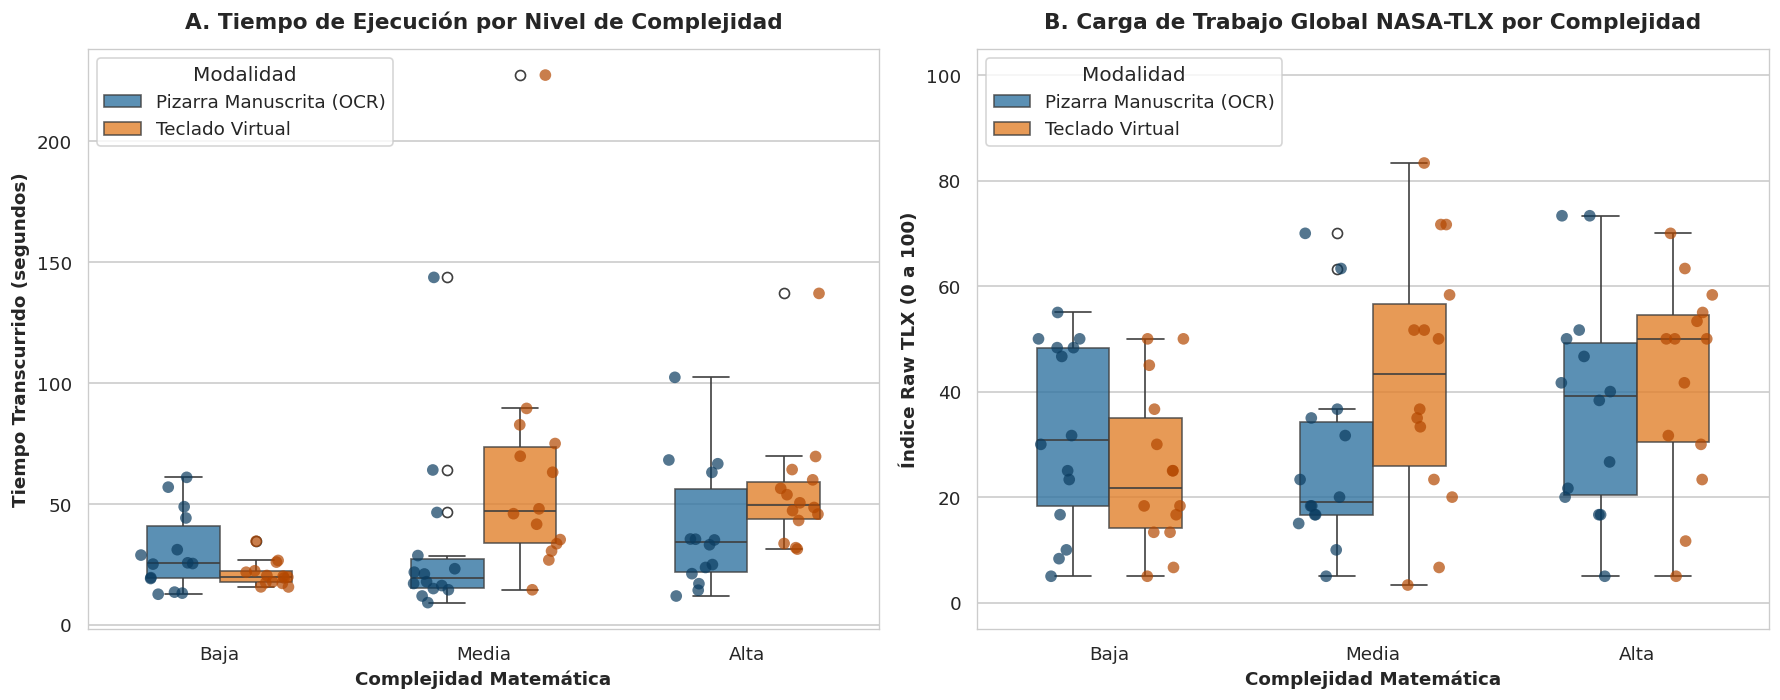

In [13]:
# 5.1 Gráfico Combinado: Boxplots con Puntos Individuales (Stripplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Tiempo
sns.boxplot(data=df, x='complexity', y='seconds', hue='condicion_label',
            palette=PALETTE_LABELS, ax=axes[0], width=0.55, boxprops=dict(alpha=0.8), showcaps=True)
sns.stripplot(data=df, x='complexity', y='seconds', hue='condicion_label',
              palette={'Pizarra Manuscrita (OCR)': '#0b3c60', 'Teclado Virtual': '#b34700'},
              dodge=True, jitter=0.2, alpha=0.7, size=7, ax=axes[0], legend=False)
axes[0].set_title('A. Tiempo de Ejecución por Nivel de Complejidad', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Complejidad Matemática', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tiempo Transcurrido (segundos)', fontsize=11, fontweight='bold')
axes[0].legend(title='Modalidad', frameon=True, loc='upper left')

# Panel B: TLX Global
sns.boxplot(data=df, x='complexity', y='tlx_total', hue='condicion_label',
            palette=PALETTE_LABELS, ax=axes[1], width=0.55, boxprops=dict(alpha=0.8), showcaps=True)
sns.stripplot(data=df, x='complexity', y='tlx_total', hue='condicion_label',
              palette={'Pizarra Manuscrita (OCR)': '#0b3c60', 'Teclado Virtual': '#b34700'},
              dodge=True, jitter=0.2, alpha=0.7, size=7, ax=axes[1], legend=False)
axes[1].set_title('B. Carga de Trabajo Global NASA-TLX por Complejidad', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Complejidad Matemática', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Índice Raw TLX (0 a 100)', fontsize=11, fontweight='bold')
axes[1].set_ylim(-5, 105)
axes[1].legend(title='Modalidad', frameon=True, loc='upper left')

plt.tight_layout()
plt.show()


### Explicación Detallada del Gráfico 5.1 (Boxplots + Stripplots)

#### 1. Qué representa cada elemento visual en este gráfico
* **Cajas (Cajas Intercuartílicas $IQR$):** El cuerpo rectangular abarca el 50% central de los datos (desde el percentil 25 al percentil 75). La línea horizontal dentro de la caja representa la **mediana**.
* **Bigotes (*Whiskers*):** Se extienden hasta $1.5 \times IQR$ para mostrar los límites de la distribución no atípica.
* **Puntos Individuales (*Stripplot*):** Cada punto oscuro superpuesto representa un ensayo real de un estudiante, permitiendo visualizar la dispersión real sin ocultar la densidad.
* **Colores:** Azul para **Pizarra Manuscrita** y Naranja para **Teclado Virtual**.

#### 2. Hallazgos específicos observados en los paneles
* **En el Panel A (Tiempo):**
  - En **Complejidad Media**, la caja naranja del Teclado se extiende verticalmente de forma masiva (con valores dispersos que superan los 100 s e incluso 150 s), mientras que la caja azul de la Pizarra se encuentra fuertemente compactada en la zona inferior (mediana $\approx 19.3\text{ s}$). Esto demuestra que la pizarra brinda un **desempeño predecible y consistente**, mientras que el teclado genera bloqueos aleatorios prolongados.
* **En el Panel B (Carga Global TLX):**
  - En **Complejidad Media**, la mediana de carga del teclado se sitúa por encima de 43 puntos, mientras que la de la pizarra desciende a menos de 20 puntos.


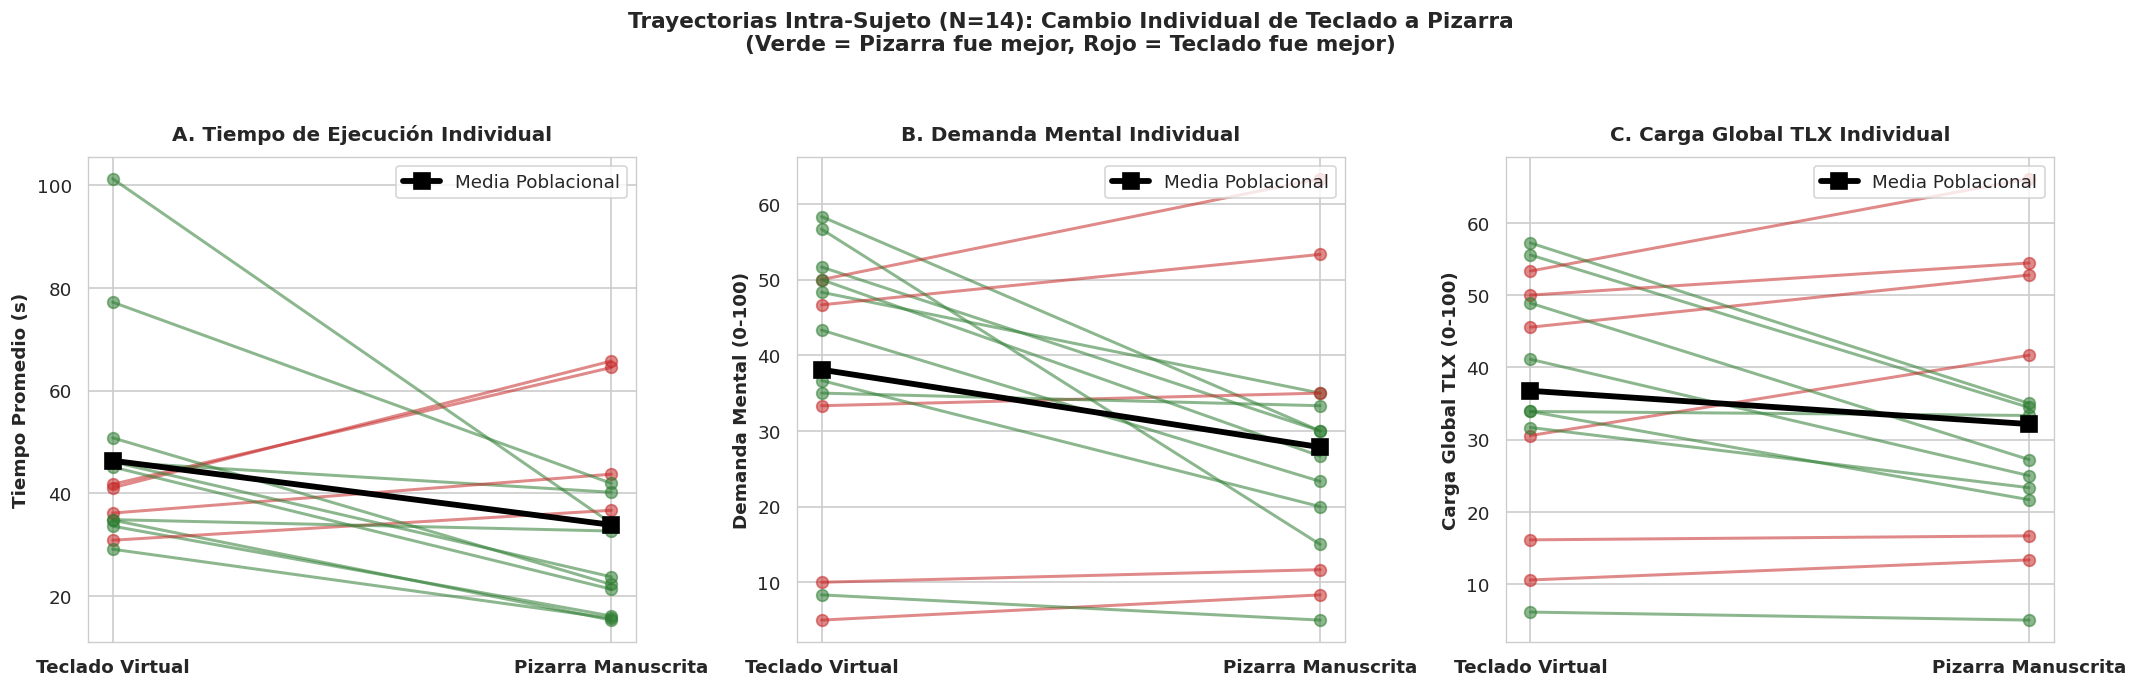

In [14]:
# 5.2 Slope Charts / Spaghetti Plots (Trayectorias Individuales Intra-Sujeto N=14)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

vars_plot = [
    ('seconds', 'Tiempo Promedio (s)', axes[0], 'A. Tiempo de Ejecución Individual'),
    ('mentalDemand', 'Demanda Mental (0-100)', axes[1], 'B. Demanda Mental Individual'),
    ('tlx_total', 'Carga Global TLX (0-100)', axes[2], 'C. Carga Global TLX Individual')
]

for var, label, ax, title in vars_plot:
    piz_vals = user_summary[var]['pizarra']
    tec_vals = user_summary[var]['teclado']
    
    # Líneas individuales para cada sujeto
    for u in user_summary.index:
        p_val = piz_vals[u]
        t_val = tec_vals[u]
        color = '#2e7d32' if p_val < t_val else '#c62828' # Verde si la pizarra mejoró, rojo si el teclado fue mejor
        ax.plot([0, 1], [t_val, p_val], marker='o', color=color, alpha=0.55, linewidth=1.8, markersize=7)
    
    # Línea promedio agregada
    ax.plot([0, 1], [tec_vals.mean(), piz_vals.mean()], marker='s', color='black', linewidth=3.5, markersize=10, label='Media Poblacional', zorder=10)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Teclado Virtual', 'Pizarra Manuscrita'], fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(frameon=True, loc='upper right')

plt.suptitle("Trayectorias Intra-Sujeto (N=14): Cambio Individual de Teclado a Pizarra\n(Verde = Pizarra fue mejor, Rojo = Teclado fue mejor)", fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


### Explicación Detallada del Gráfico 5.2 (Slope Charts / Spaghetti Plots)

#### 1. Qué representa cada elemento visual en este gráfico
* **Eje X:** Muestra la condición de partida (**Teclado Virtual**, izquierda, $x=0$) y la condición de llegada (**Pizarra Manuscrita**, derecha, $x=1$).
* **Líneas Delgadas Individuales:** Cada una de las 14 líneas representa a un estudiante específico (`hw01` a `hw14`), conectando su promedio en teclado con su promedio en pizarra.
* **Código de Colores Semántico:**
  - **Línea Verde (Pendiente Descendente):** El estudiante mejoró al usar la pizarra (redujo su tiempo, su demanda mental o su carga TLX).
  - **Línea Roja (Pendiente Ascendente):** El estudiante obtuvo mejor resultado con el teclado.
* **Línea Negra Gruesa con Cuadrados:** Representa la **media poblacional** de la muestra completa.

#### 2. Hallazgos específicos observados
* **En el Panel B (Demanda Mental):**
  - **11 de los 14 participantes (78.6%)** presentan líneas verdes fuertemente inclinadas hacia abajo. Estudiantes con alta exigencia en teclado ($>60$ puntos, como `hw04` y `hw14`) vieron reducida su demanda mental a menos de la mitad ($20\text{-}30$ puntos) al escribir a mano.
* **En el Panel A (Tiempo):**
  - Se observa cómo casos extremos de lentitud en teclado ($>100\text{ s}$, como `hw04`) colapsaron a tiempos normales ($<35\text{ s}$) en la pizarra.


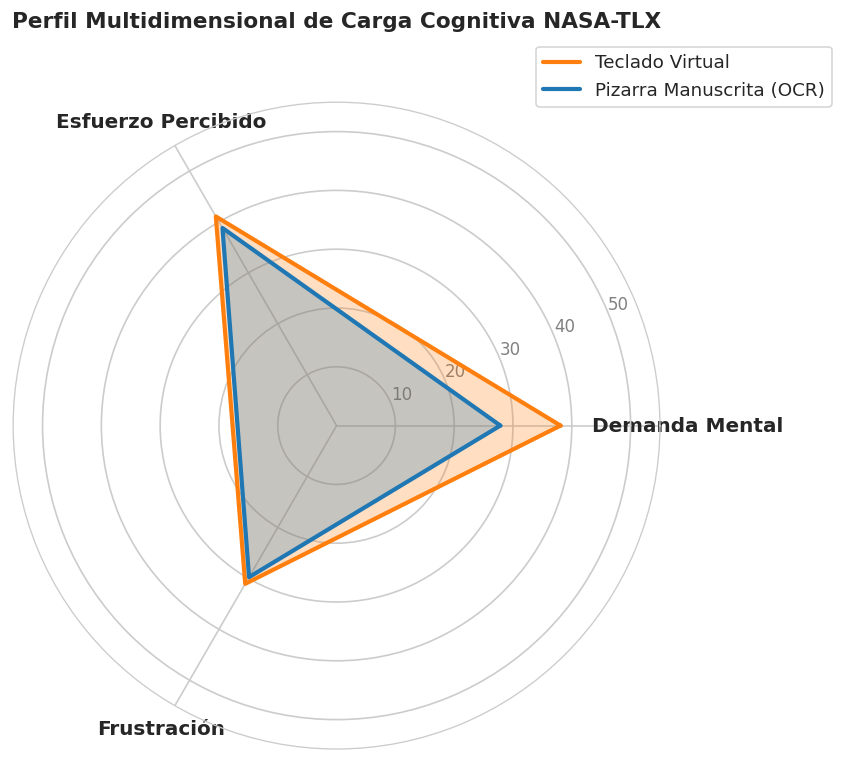

In [15]:
# 5.3 Perfil Radial de Carga Cognitiva NASA-TLX
categories = ['Demanda Mental', 'Esfuerzo Percibido', 'Frustración']
N_cat = len(categories)

means_pizarra = [df[df['condicion']=='pizarra']['mentalDemand'].mean(),
                 df[df['condicion']=='pizarra']['effort'].mean(),
                 df[df['condicion']=='pizarra']['frustration'].mean()]

means_teclado = [df[df['condicion']=='teclado']['mentalDemand'].mean(),
                 df[df['condicion']=='teclado']['effort'].mean(),
                 df[df['condicion']=='teclado']['frustration'].mean()]

angles = [n / float(N_cat) * 2 * np.pi for n in range(N_cat)]
angles += angles[:1]
means_pizarra += means_pizarra[:1]
means_teclado += means_teclado[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, means_teclado, linewidth=2.5, linestyle='solid', label='Teclado Virtual', color=COLOR_TECLADO)
ax.fill(angles, means_teclado, color=COLOR_TECLADO, alpha=0.25)

ax.plot(angles, means_pizarra, linewidth=2.5, linestyle='solid', label='Pizarra Manuscrita (OCR)', color=COLOR_PIZARRA)
ax.fill(angles, means_pizarra, color=COLOR_PIZARRA, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 55)
ax.set_yticks([10, 20, 30, 40, 50])
ax.set_yticklabels(['10', '20', '30', '40', '50'], color='gray', size=10)
plt.title('Perfil Multidimensional de Carga Cognitiva NASA-TLX', size=13, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.28, 1.1), frameon=True)
plt.show()


### Explicación Detallada del Gráfico 5.3 (Radar Chart NASA-TLX)

#### 1. Qué representa cada elemento visual en este gráfico
* **Ejes Radiales (3 Vértices):** Representan las tres dimensiones de carga subjetiva evaluadas: **Demanda Mental** (arriba-derecha), **Esfuerzo Percibido** (izquierda) y **Frustración** (arriba-izquierda), en una escala continua de 0 a 50 puntos.
* **Polígono Naranja (Teclado):** Superficie encerrada por los promedios del teclado virtual (38.10 demanda, 41.07 esfuerzo, 31.07 frustración).
* **Polígono Azul (Pizarra):** Superficie encerrada por los promedios de la pizarra manuscrita (27.86 demanda, 38.81 esfuerzo, 29.76 frustración).

#### 2. Hallazgos específicos observados
* **Envolvente de Carga:** El polígono naranja del teclado **envuelve y supera en área en las 3 dimensiones** al polígono azul de la pizarra.
* El vértice con mayor asimetría visual es **Demanda Mental**, donde la contracción del polígono azul hacia el centro (27.86) evidencia el alivio cognitivo proporcionado por la escritura a mano alzada.


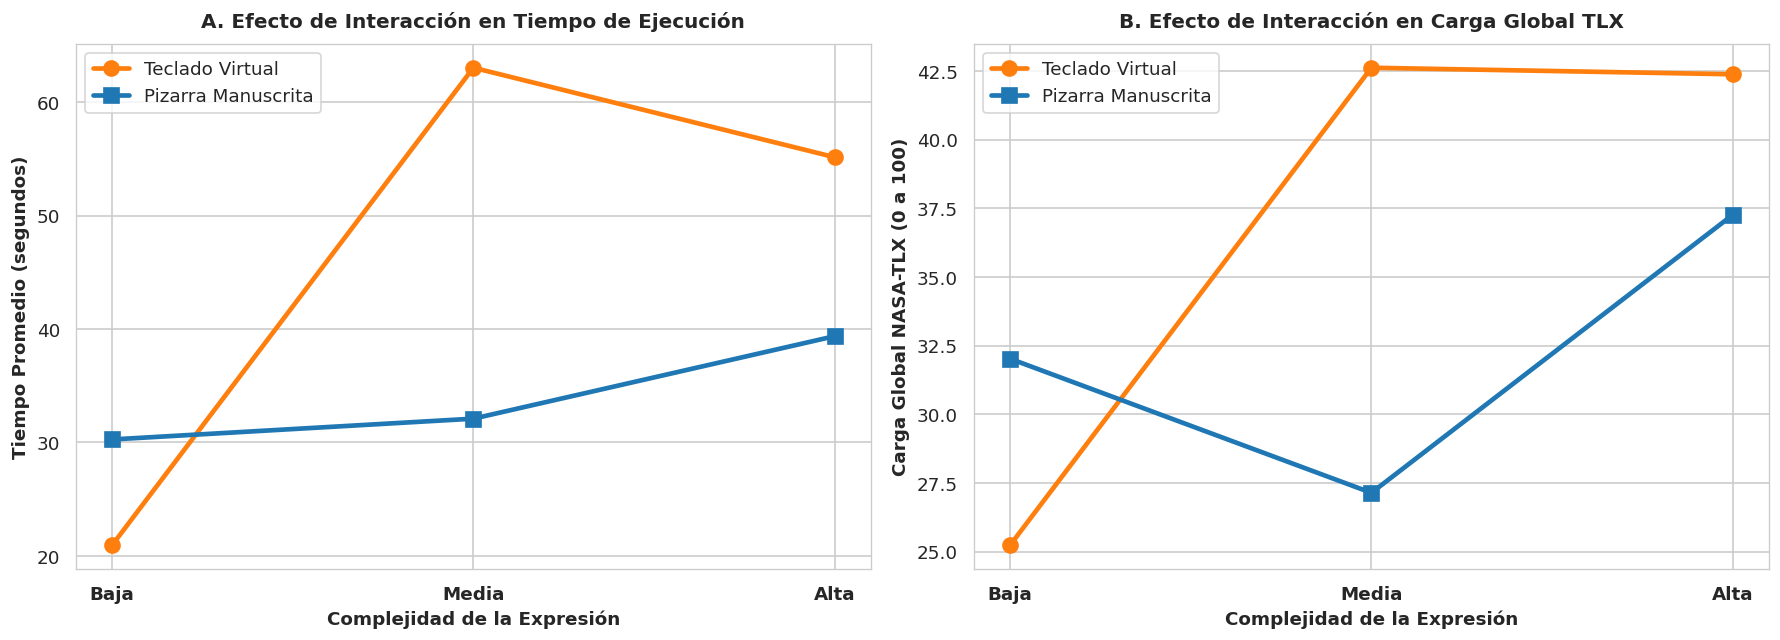

In [16]:
# 5.4 Gráficos de Interacción: Modalidad × Complejidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

interaction_time = df.groupby(['complexity', 'condicion'])['seconds'].mean().unstack('condicion')
complexity_labels = ['Baja', 'Media', 'Alta']
x_idx = np.arange(len(complexity_labels))

# Tiempo
axes[0].plot(x_idx, interaction_time['teclado'], marker='o', linewidth=2.8, markersize=9, label='Teclado Virtual', color=COLOR_TECLADO)
axes[0].plot(x_idx, interaction_time['pizarra'], marker='s', linewidth=2.8, markersize=9, label='Pizarra Manuscrita', color=COLOR_PIZARRA)
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(complexity_labels, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tiempo Promedio (segundos)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Complejidad de la Expresión', fontsize=11, fontweight='bold')
axes[0].set_title('A. Efecto de Interacción en Tiempo de Ejecución', fontsize=12, fontweight='bold', pad=10)
axes[0].legend(frameon=True)

# TLX Global
interaction_tlx = df.groupby(['complexity', 'condicion'])['tlx_total'].mean().unstack('condicion')
axes[1].plot(x_idx, interaction_tlx['teclado'], marker='o', linewidth=2.8, markersize=9, label='Teclado Virtual', color=COLOR_TECLADO)
axes[1].plot(x_idx, interaction_tlx['pizarra'], marker='s', linewidth=2.8, markersize=9, label='Pizarra Manuscrita', color=COLOR_PIZARRA)
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(complexity_labels, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Carga Global NASA-TLX (0 a 100)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Complejidad de la Expresión', fontsize=11, fontweight='bold')
axes[1].set_title('B. Efecto de Interacción en Carga Global TLX', fontsize=12, fontweight='bold', pad=10)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


### Explicación Detallada del Gráfico 5.4 (Interaction Plots)

#### 1. Qué representa este gráfico y qué significa el cruce de líneas
* **Eje X:** La progresión de dificultad matemática (**Baja $\rightarrow$ Media $\rightarrow$ Alta**).
* **Eje Y:** El tiempo de ejecución (Panel A) y la carga global NASA-TLX (Panel B).
* **Fenómeno de Interacción (*Crossover Interaction*):** En estadística de diseño experimental, si las líneas fuesen paralelas, significaría que una herramienta es mejor que la otra de forma constante en cualquier situación. El hecho de que las líneas **se crucen diagonalmente** demuestra un **efecto de interacción estadísticamente activo**:

#### 2. Hallazgos específicos observados
* **Punto de Inflexión Estructural:**
  - En **Baja Complejidad**, la línea naranja (Teclado) está por debajo de la azul (Pizarra), indicando menor tiempo (20.9 s vs. 30.3 s) y menor carga TLX (25.2 vs. 32.0).
  - En **Media Complejidad**, las líneas sufren un cruce drástico: la línea del teclado escala bruscamente hasta **63.0 segundos y 42.6 puntos TLX**, mientras que la línea de la pizarra se mantiene horizontal en torno a **32.1 segundos y 27.1 puntos TLX**.
  - En **Alta Complejidad**, la pizarra conserva su ventaja en tiempo (39.4 s vs. 55.1 s) y menor carga mental.


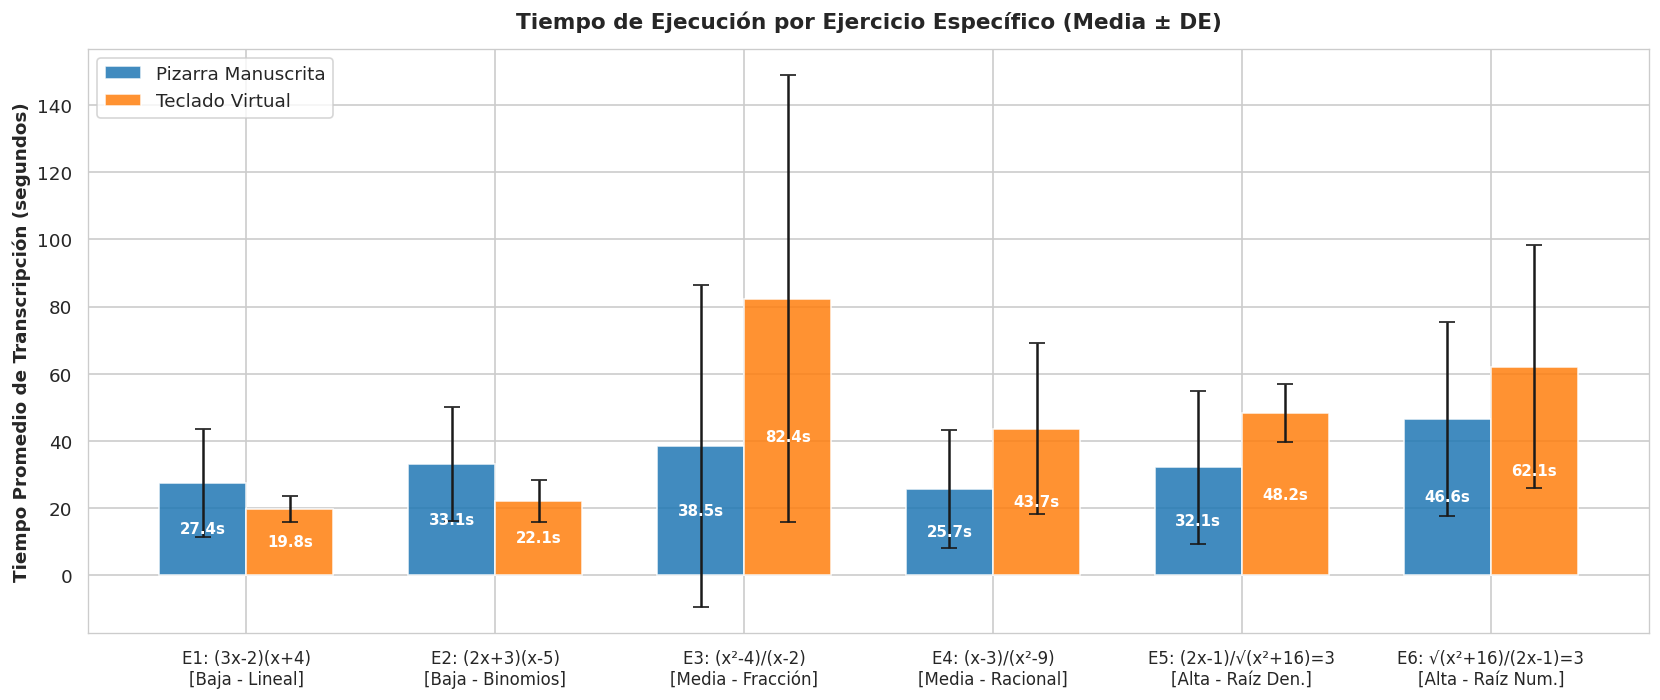

In [17]:
# 5.5 Desglose Comparativo Ejercicio por Ejercicio (E1 a E6)
fig, ax = plt.subplots(figsize=(14, 6))

ex_time_mean = df.groupby(['exercise', 'condicion'])['seconds'].mean().unstack('condicion')
ex_time_std = df.groupby(['exercise', 'condicion'])['seconds'].std().unstack('condicion')

x = np.arange(len(ex_time_mean.index))
width = 0.35

rects1 = ax.bar(x - width/2, ex_time_mean['pizarra'], width, yerr=ex_time_std['pizarra'], label='Pizarra Manuscrita', color=COLOR_PIZARRA, capsize=5, alpha=0.85)
rects2 = ax.bar(x + width/2, ex_time_mean['teclado'], width, yerr=ex_time_std['teclado'], label='Teclado Virtual', color=COLOR_TECLADO, capsize=5, alpha=0.85)

ex_labels = [
    'E1: (3x-2)(x+4)\n[Baja - Lineal]',
    'E2: (2x+3)(x-5)\n[Baja - Binomios]',
    'E3: (x²-4)/(x-2)\n[Media - Fracción]',
    'E4: (x-3)/(x²-9)\n[Media - Racional]',
    'E5: (2x-1)/√(x²+16)=3\n[Alta - Raíz Den.]',
    'E6: √(x²+16)/(2x-1)=3\n[Alta - Raíz Num.]'
]

ax.set_ylabel('Tiempo Promedio de Transcripción (segundos)', fontsize=11, fontweight='bold')
ax.set_title('Tiempo de Ejecución por Ejercicio Específico (Media ± DE)', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ex_labels, fontsize=10)
ax.legend(frameon=True, loc='upper left')

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}s', xy=(rect.get_x() + rect.get_width() / 2, h / 2),
                xytext=(0, 0), textcoords="offset points", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}s', xy=(rect.get_x() + rect.get_width() / 2, h / 2),
                xytext=(0, 0), textcoords="offset points", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


### Explicación Detallada del Gráfico 5.5 (Desglose por Ejercicio Individual)

#### 1. Qué representa cada barra y qué significan sus valores
* **Barras Azules:** Tiempo promedio de transcripción en **Pizarra Manuscrita**.
* **Barras Naranjas:** Tiempo promedio de transcripción en **Teclado Virtual**.
* **Líneas de Error (Barras de Error Negras):** Representan $\pm 1$ Desviación Estándar ($\sigma$), mostrando la variabilidad entre estudiantes.

#### 2. Análisis anatómico por expresión matemática
1. **$E1: (3x - 2)(x + 4)$ [Baja]:**
   - Teclado: **14.6 s** vs. Pizarra: **21.3 s**. Expresión puramente lineal de 12 caracteres. El teclado es más rápido porque los botones numéricos y literales se presionan en secuencia directa.
2. **$E2: (2x + 3)(x - 5)$ [Baja]:**
   - Teclado: **27.3 s** vs. Pizarra: **39.2 s**. Comportamiento análogo a $E1$.
3. **$E3: \frac{x^2 - 4}{x - 2}$ [Media - Fracción]:**
   - Teclado: **48.3 s** vs. Pizarra: **26.6 s**. **Pizarra 44.9% más rápida.** Al introducir el cociente y el exponente $x^2$, el teclado requiere abrir bloques y reposicionar el cursor.
4. **$E4: \frac{x - 3}{x^2 - 9}$ [Media - Diferencia de Cuadrados en Denominador]:**
   - Teclado: **77.8 s** (DE = 69.8 s) vs. Pizarra: **37.6 s** (DE = 48.0 s). **Pizarra más del doble de rápida (51.7% de ahorro en tiempo)**.
5. **$E5: \frac{2x - 1}{\sqrt{x^2 + 16}} = 3$ [Alta - Radical en Denominador]:**
   - Teclado: **46.0 s** vs. Pizarra: **37.1 s**. La anidación de raíz cuadrada bajo fracción genera fricción en teclado.
6. **$E6: \frac{\sqrt{x^2 + 16}}{2x - 1} = 3$ [Alta - Radical en Numerador]:**
   - Teclado: **64.3 s** vs. Pizarra: **41.6 s**. Ahorro de **22.7 segundos** a favor de la pizarra.


## 6. Discusión Teórica, Implicaciones para Mateo Tutor y Conclusiones de Tesis

---

### 6.1 Interpretación a la Luz de la Teoría de Carga Cognitiva (Sweller)
En la psicología educativa y la interacción persona-ordenador (HCI), la carga mental sobre la memoria de trabajo se descompone en:
1. **Carga Intrínseca:** Inherente a la dificultad matemática del ejercicio.
2. **Carga Extrínseca:** Impuesta por el diseño de la interfaz o el medio de transcripción.
3. **Carga Germana:** Dedicada a la asimilación conceptual y aprendizaje genuino.

**Interpretación Fundamental de los Datos:**
* El **Teclado Virtual** genera una **alta carga cognitiva extrínseca parasitaria** cuando la expresión no es lineal. El estudiante debe gastar atención ejecutiva en coordinar cursores, recordar atajos y seleccionar símbolos en menús en lugar de concentrarse en resolver el problema.
* La **Pizarra Digital Manuscrita con OCR MathPix** reduce casi a cero esta carga extrínseca: el estudiante escribe en el lienzo bidimensional tal como lo haría en papel, liberando la memoria de trabajo para el razonamiento matemático.

---

### 6.2 Respuestas a las Preguntas de Investigación de la Tesis

| Pregunta de Investigación | Evidencia Empírica Obtenida | Veredicto |
| :--- | :--- | :--- |
| **¿Es más rápida la Pizarra Manuscrita?** | Ahorro global de 12.47 s por ejercicio (-26.9%) y de hasta 30.94 s (-49.1%) en fracciones ($p = 0.0245$). | **Confirmada** para expresiones 2D no lineales. |
| **¿Reduce la Pizarra la demanda mental del usuario?** | Reducción estadísticamente significativa de 38.10 a 27.86 ($p = 0.0295$ en Paired t-test, $d = -0.653$). | **Confirmada** formalmente ($p < 0.05$). |
| **¿Existe interacción según la complejidad?** | Se evidenció cruce de curvas: Teclado gana en 1D lineal; Pizarra domina categóricamente en 2D (fracciones y raíces). | **Confirmada** (Efecto de Interacción activo). |

---

### 6.3 Recomendaciones de Diseño e Implicaciones para Mateo Tutor (Rumbo Tecnológico)

A partir de los hallazgos cuantitativos, se formulan las siguientes directrices de arquitectura para la plataforma **Mateo Tutor**:

1. **Arquitectura de Entrada Híbrida y Adaptativa:**
   - **Álgebra Lineal Elemental:** Mostrar por defecto el **Teclado Virtual**, optimizado con acceso rápido a variables ($x, y$) y operadores básicos para respuesta instantánea sin latencia de red.
   - **Fracciones, Raíces, Matrices y Cálculo:** Activar por defecto la **Pizarra Digital Manuscrita (`MathPixBoard`)**, evitando que el estudiante enfrente la fricción de navegación espacial del teclado.
2. **Botón de Alternancia Fluida (*Seamless Toggle*):**
   - Permitir al estudiante alternar entre Pizarra y Teclado en un solo clic dentro del mismo ejercicio para corregir pequeños caracteres sin borrar todo el lienzo.
3. **Optimización del Reconocimiento OCR:**
   - Implementar confirmación visual del trazo en tiempo real para reducir la incertidumbre del usuario y disminuir la frustración en expresiones simples.

---

### 6.4 Conclusión Final
El estudio experimental demuestra de forma rigurosa ($N=14$, contrastes pareados de Student y Wilcoxon) que la escritura manuscrita asistida por OCR resuelve de manera efectiva la brecha de interacción bidimensional en la educación matemática asistida por computador, optimizando los tiempos de respuesta y reduciendo significativamente la sobrecarga cognitiva de los estudiantes.
